## Load in packages and data

In [1]:
import numpy as np
import pandas as pd
# import geopandas as gpd
import matplotlib.pyplot as plt
import matsim_output_analysis_flex as moa
import operator

In [2]:
df_pl = pd.read_csv(r"220426_plans_alternates.csv") 
df_ex = pd.read_csv(r"220426_experienced_plans_alternates.csv") 
df_ex = df_ex[["id", "selected plan activity_type_or_mode", "selected plan utility", "selected plan duration", "selected plan distance_travelled", "selected plan routes", "selected plan boardingTime", "selected plan location"]]
df_ex.columns = ["id" , "experienced plan activity_type_or_mode", "experienced plan utility", "experienced plan duration", "experienced plan distance_travelled", "experienced plan routes", "experienced plan boardingTime", "experienced plan location"]

# #the following is only needed for handling experienced plans
# df["stuck_bool"] =  (df["selected plan activity_type_or_mode"] != df["planned plan activity_type_or_mode"]).astype(int) #so the bool tells us: 1 if stuck, 0 if not stuck

In [39]:
df = pd.merge(df_pl, df_ex, how = "outer", on="id")

In [40]:
df = df[~df["unselected plan (1) activity_type_or_mode"].isna()]

In [41]:
diffs1 = df[df["selected plan utility"]!= df["unselected plan (1) utility"]]
print(f"there are {len(diffs1)} agents with varying utility; {(len(diffs1)/(len(df)) * 100)}% of the population")

there are 59 agents with varying utility; 60.824742268041234% of the population


In [42]:
diffs2 = df[df["selected plan activity_type_or_mode"]!= df["unselected plan (1) activity_type_or_mode"]]
print(f"there are {len(diffs2)} agents with varying plans; {(len(diffs2)/(len(df)) * 100)}% of the population")

there are 17 agents with varying plans; 17.525773195876287% of the population


In [43]:
# check for agents who do not complete their planned plan in their selected plan
df["stuck_selected"] =  (df["selected plan activity_type_or_mode"] != df["experienced plan activity_type_or_mode"]).astype(int) #so the bool tells us: 1 if stuck, 0 if not stuck

#TODO: check for agents who do not complete their planned plan in their unselected plan
# df["stuck_unselected"] = (df["selected plan activity_type_or_mode"] != df["unselected plan (1) activity_type_or_mode"]).astype(int) #so the bool tells us: 1 if stuck, 0 if not stuck

In [44]:
# remove those who are stuck 
#TODO: figure out a more elegant way to handle these
df = df[df["stuck_selected"]==0]
# df = df[df["stuck_unselected"]==0]

In [45]:
#turn plan summaries into lists instead of long strings
df['selected plan activity_type_or_mode'] = df['selected plan activity_type_or_mode'].str.split('; ')
df['selected plan distance_travelled'] = df['selected plan distance_travelled'].str.split('; ')
df['selected plan duration'] = df['selected plan duration'].str.split('; ')
df['selected plan location'] = df['selected plan location'].str.split('; ')
df['selected plan routes'] = df['selected plan routes'].str.split('; ')
df['selected plan boardingTime'] = df['selected plan boardingTime'].str.split('; ')

In [46]:
df['experienced plan activity_type_or_mode'] = df['experienced plan activity_type_or_mode'].str.split('; ')
df['experienced plan distance_travelled'] = df['experienced plan distance_travelled'].str.split('; ')
df['experienced plan duration'] = df['experienced plan duration'].str.split('; ')
df['experienced plan location'] = df['experienced plan location'].str.split('; ')
df['experienced plan routes'] = df['experienced plan routes'].str.split('; ')
df['experienced plan boardingTime'] = df['experienced plan boardingTime'].str.split('; ')

In [47]:
df['unselected plan (1) activity_type_or_mode'] = df['unselected plan (1) activity_type_or_mode'].str.split('; ')
df['unselected plan (1) distance_travelled'] = df['unselected plan (1) distance_travelled'].str.split('; ')
df['unselected plan (1) duration'] = df['unselected plan (1) duration'].str.split('; ')
df['unselected plan (1) location'] = df['unselected plan (1) location'].str.split('; ')
df['unselected plan (1) routes'] = df['unselected plan (1) routes'].str.split('; ')
df['unselected plan (1) boardingTime'] = df['unselected plan (1) boardingTime'].str.split('; ')

## Remove "pt interaction" terms and all corresponding columns

In [48]:
#extract the indices of where pt interaction happens
df['selected plan ptinteraction_indices'] = df['selected plan activity_type_or_mode'].apply(moa.get_ptinteraction_index)
df['experienced plan ptinteraction_indices'] = df['experienced plan activity_type_or_mode'].apply(moa.get_ptinteraction_index)
df['unselected plan (1) ptinteraction_indices'] = df['unselected plan (1) activity_type_or_mode'].apply(moa.get_ptinteraction_index)

In [49]:
#remove the pt interaction activities
df['selected plan activity_type_or_mode'] = df.apply(lambda row: moa.remove_ptinteraction(row['selected plan ptinteraction_indices'], row['selected plan activity_type_or_mode']), axis=1)
df['experienced plan activity_type_or_mode'] = df.apply(lambda row: moa.remove_ptinteraction(row['experienced plan ptinteraction_indices'], row['experienced plan activity_type_or_mode']), axis=1)
df['unselected plan (1) activity_type_or_mode'] = df.apply(lambda row: moa.remove_ptinteraction(row['unselected plan (1) ptinteraction_indices'], row['unselected plan (1) activity_type_or_mode']), axis=1)

In [50]:
#remove the correspinding pt interaction durations
df['selected plan duration'] = df.apply(lambda row: moa.remove_ptinteraction(row['selected plan ptinteraction_indices'], row['selected plan duration']), axis=1)
df['experienced plan duration'] = df.apply(lambda row: moa.remove_ptinteraction(row['experienced plan ptinteraction_indices'], row['experienced plan duration']), axis=1)
df['unselected plan (1) duration'] = df.apply(lambda row: moa.remove_ptinteraction(row['unselected plan (1) ptinteraction_indices'], row['unselected plan (1) duration']), axis=1)

In [51]:
#remove the correspinding pt interaction locations
df['selected plan location'] = df.apply(lambda row: moa.remove_ptinteraction(row['selected plan ptinteraction_indices'], row['selected plan location']), axis=1)
df['experienced plan location'] = df.apply(lambda row: moa.remove_ptinteraction(row['experienced plan ptinteraction_indices'], row['experienced plan location']), axis=1)
df['unselected plan (1) location'] = df.apply(lambda row: moa.remove_ptinteraction(row['unselected plan (1) ptinteraction_indices'], row['unselected plan (1) location']), axis=1)

In [52]:
#remove the correspinding pt interaction distance travelled
df['selected plan distance_travelled'] = df.apply(lambda row: moa.remove_ptinteraction(row['selected plan ptinteraction_indices'], row['selected plan distance_travelled']), axis=1)
df['experienced plan distance_travelled'] = df.apply(lambda row: moa.remove_ptinteraction(row['experienced plan ptinteraction_indices'], row['experienced plan distance_travelled']), axis=1)
df['unselected plan (1) distance_travelled'] = df.apply(lambda row: moa.remove_ptinteraction(row['unselected plan (1) ptinteraction_indices'], row['unselected plan (1) distance_travelled']), axis=1)

In [53]:
#remove the correspinding pt interaction distance travelled
df['selected plan boardingTime'] = df.apply(lambda row: moa.remove_ptinteraction(row['selected plan ptinteraction_indices'], row['selected plan boardingTime']), axis=1)
df['experienced plan boardingTime'] = df.apply(lambda row: moa.remove_ptinteraction(row['experienced plan ptinteraction_indices'], row['experienced plan boardingTime']), axis=1)
df['unselected plan (1) boardingTime'] = df.apply(lambda row: moa.remove_ptinteraction(row['unselected plan (1) ptinteraction_indices'], row['unselected plan (1) boardingTime']), axis=1)

In [54]:
#remove the correspinding pt interaction distance travelled
df['selected plan routes'] = df.apply(lambda row: moa.remove_ptinteraction(row['selected plan ptinteraction_indices'], row['selected plan routes']), axis=1)
df['experienced plan routes'] = df.apply(lambda row: moa.remove_ptinteraction(row['experienced plan ptinteraction_indices'], row['experienced plan routes']), axis=1)
df['unselected plan (1) routes'] = df.apply(lambda row: moa.remove_ptinteraction(row['unselected plan (1) ptinteraction_indices'], row['unselected plan (1) routes']), axis=1)

In [55]:
#clean  up table and remove indices
df = df.drop(["selected plan ptinteraction_indices","unselected plan (1) ptinteraction_indices", "experienced plan ptinteraction_indices",
              "unselected plan (2) activity_type_or_mode", "unselected plan (2) distance_travelled", "unselected plan (2) duration", "unselected plan (2) location",  "unselected plan (2) number", "unselected plan (2) utility",
              "unselected plan (3) activity_type_or_mode", "unselected plan (3) distance_travelled", "unselected plan (3) duration", "unselected plan (3) location",  "unselected plan (3) number", "unselected plan (3) utility",
              "unselected plan (4) activity_type_or_mode", "unselected plan (4) distance_travelled", "unselected plan (4) duration", "unselected plan (4) location", "unselected plan (4) number", "unselected plan (4) utility"], axis=1)

## Calculating utility components

Get activity start and end times, and highlight any "stuck" agents

In [56]:
def update_last_element(lst):
    if isinstance(lst, list) and len(lst) > 0:
        lst[-1] = "24:00:00"
    return lst

df['selected plan duration'] =  df.apply(lambda row: update_last_element(row['selected plan duration']), axis=1)
df['experienced plan duration'] =  df.apply(lambda row: update_last_element(row['experienced plan duration']), axis=1)
df['unselected plan (1) duration'] =  df.apply(lambda row: update_last_element(row['unselected plan (1) duration']), axis=1)

In [57]:
df["sp_legs_indices"] = df["selected plan activity_type_or_mode"].apply(moa.get_trips_indices_only)
df["sp_activities_indices"] = df["selected plan activity_type_or_mode"].apply(moa.get_activities_indices_only)
df["sp_leg_durations"] = df.apply(lambda row: moa.get_trips_duration_or_mode(row["sp_legs_indices"], row["selected plan duration"]), axis=1)
df["sp_activity_durations"] = df.apply(lambda row: moa.get_trips_duration_or_mode(row["sp_activities_indices"], row["selected plan duration"]), axis=1)


In [58]:
df["ep_legs_indices"] = df["experienced plan activity_type_or_mode"].apply(moa.get_trips_indices_only)
df["ep_activities_indices"] = df["experienced plan activity_type_or_mode"].apply(moa.get_activities_indices_only)
df["ep_leg_durations"] = df.apply(lambda row: moa.get_trips_duration_or_mode(row["ep_legs_indices"], row["experienced plan duration"]), axis=1)
df["ep_activity_durations"] = df.apply(lambda row: moa.get_trips_duration_or_mode(row["ep_activities_indices"], row["experienced plan duration"]), axis=1)

In [59]:
df["up1_legs_indices"] = df["unselected plan (1) activity_type_or_mode"].apply(moa.get_trips_indices_only)
df["up1_activities_indices"] = df["unselected plan (1) activity_type_or_mode"].apply(moa.get_activities_indices_only)
df["up1_leg_durations"] = df.apply(lambda row: moa.get_trips_duration_or_mode(row["up1_legs_indices"], row["unselected plan (1) duration"]), axis=1)
df["up1_activity_durations"] = df.apply(lambda row: moa.get_trips_duration_or_mode(row["up1_activities_indices"], row["unselected plan (1) duration"]), axis=1)

In [60]:
df[["sp_activity_starts", "sp_activity_ends","sp_stuck_index"]] = df.apply(lambda row: moa.get_activity_timings(row["sp_activities_indices"], row["selected plan duration"], row["selected plan activity_type_or_mode"]), axis=1, result_type="expand")
df[["ep_activity_starts", "ep_activity_ends","ep_stuck_index"]] = df.apply(lambda row: moa.get_activity_timings(row["ep_activities_indices"], row["experienced plan duration"], row["experienced plan activity_type_or_mode"]), axis=1, result_type="expand")
df[["up1_activity_starts", "up1_activity_ends","up1_stuck_index"]] = df.apply(lambda row: moa.get_activity_timings(row["up1_activities_indices"], row["unselected plan (1) duration"], row["unselected plan (1) activity_type_or_mode"]), axis=1, result_type="expand")

In [61]:
df["sp_calculated_activity_durations"] = df.apply(lambda row: moa.get_activity_durations(row["sp_activity_starts"], row["sp_activity_ends"], row["selected plan activity_type_or_mode"], row["sp_stuck_index"],), axis=1)
df["ep_calculated_activity_durations"] = df.apply(lambda row: moa.get_activity_durations(row["ep_activity_starts"], row["ep_activity_ends"], row["experienced plan activity_type_or_mode"], row["ep_stuck_index"],), axis=1)
df["up1_calculated_activity_durations"] = df.apply(lambda row: moa.get_activity_durations(row["up1_activity_starts"], row["up1_activity_ends"], row["unselected plan (1) activity_type_or_mode"], row["up1_stuck_index"]), axis=1)

In [62]:
df["sp_activities"] = df.apply(lambda row: moa.get_activities(row["selected plan activity_type_or_mode"], row["sp_activities_indices"], row["sp_stuck_index"]), axis=1) #this needs to account for stuckness
df["ep_activities"] = df.apply(lambda row: moa.get_activities(row["experienced plan activity_type_or_mode"], row["ep_activities_indices"], row["ep_stuck_index"]), axis=1) #this needs to account for stuckness
df["up1_activities"] = df.apply(lambda row: moa.get_activities(row["unselected plan (1) activity_type_or_mode"], row["up1_activities_indices"], row["up1_stuck_index"]), axis=1) #this needs to account for stuckness

Now can call activity utility function as normal, BUT ADD IN PENALTY FOR NEGATIVE OVERNIGHT DURATION

In [63]:
df["sp_calculated_activity_u"] =  df.apply(lambda row: moa.calculate_activity_utility( row["selected plan activity_type_or_mode"], row["sp_activities_indices"], row["sp_stuck_index"], row["sp_calculated_activity_durations"]), axis=1)
df["ep_calculated_activity_u"] =  df.apply(lambda row: moa.calculate_activity_utility( row["experienced plan activity_type_or_mode"], row["ep_activities_indices"], row["ep_stuck_index"], row["ep_calculated_activity_durations"]), axis=1)
df["up1_calculated_activity_u"] =  df.apply(lambda row: moa.calculate_activity_utility( row["unselected plan (1) activity_type_or_mode"], row["up1_activities_indices"], row["up1_stuck_index"], row["up1_calculated_activity_durations"]), axis=1)

Travel utility

In [64]:
#do the tolls
import xmltodict
import pprint

with open(r"C:\Users\maria\Documents\matsim_analysis\data\2040_do_minimum_40wfh_rerun_10pc_20250306\output_toll.xml", 'r', encoding='utf-8') as file:
    my_xml = file.read()
output_tolls = xmltodict.parse(my_xml)
tolls = output_tolls["roadpricing"]["links"]["link"]
tolls2  = {item['@id']: item['cost']['@amount'] for item in tolls}

In [65]:
df["sp_calculated_travel_u"] = df.apply(lambda row: moa.calculate_travel_utility(row["id"], row["selected plan activity_type_or_mode"], row["selected plan duration"], row["selected plan distance_travelled"],
                            row["sp_activities_indices"], row["subpopulation"], row["selected plan boardingTime"], 
                            row["sp_activity_ends"], row["selected plan routes"], tolls2, row["sp_stuck_index"]), axis=1)

In [66]:
df["ep_calculated_travel_u"] = df.apply(lambda row: moa.calculate_travel_utility(row["id"], row["experienced plan activity_type_or_mode"], row["experienced plan duration"], row["experienced plan distance_travelled"],
                            row["ep_activities_indices"], row["subpopulation"], row["experienced plan boardingTime"], 
                            row["ep_activity_ends"], row["experienced plan routes"], tolls2, row["ep_stuck_index"]), axis=1)

In [67]:
df["up1_calculated_travel_u"] = df.apply(lambda row: moa.calculate_travel_utility(row["id"], row["unselected plan (1) activity_type_or_mode"], row["unselected plan (1) duration"], row["unselected plan (1) distance_travelled"],
                            row["up1_activities_indices"], row["subpopulation"], row["unselected plan (1) boardingTime"], 
                            row["up1_activity_ends"], row["unselected plan (1) routes"], tolls2, row["up1_stuck_index"]), axis=1)

In [68]:
df["sp_calculated_penalty_u"] = df.apply(lambda row: moa.calculate_stuck_penalty(row["selected plan activity_type_or_mode"], row["sp_stuck_index"]), axis=1)
df["ep_calculated_penalty_u"] = df.apply(lambda row: moa.calculate_stuck_penalty(row["experienced plan activity_type_or_mode"], row["ep_stuck_index"]), axis=1)
df["up1_calculated_penalty_u"] = df.apply(lambda row: moa.calculate_stuck_penalty(row["unselected plan (1) activity_type_or_mode"], row["up1_stuck_index"]), axis=1)

Sum travel, activity, and penalty to get overall score

In [69]:
df["sp_total_travel_u"] = df.apply(lambda row: sum(row["sp_calculated_travel_u"]), axis=1)
df["ep_total_travel_u"] = df.apply(lambda row: sum(row["ep_calculated_travel_u"]), axis=1)
df["up1_total_travel_u"] = df.apply(lambda row: sum(row["up1_calculated_travel_u"]), axis=1)

In [70]:
df["sp_total_activity_u"] = df.apply(lambda row: sum(row["sp_calculated_activity_u"]), axis=1)
df["ep_total_activity_u"] = df.apply(lambda row: sum(row["ep_calculated_activity_u"]), axis=1)
df["up1_total_activity_u"] = df.apply(lambda row: sum(row["up1_calculated_activity_u"]), axis=1)

In [71]:
df["sp_calculated_total_u"] = df["sp_total_travel_u"]+df["sp_total_activity_u"]+df["sp_calculated_penalty_u"]
df["ep_calculated_total_u"] = df["ep_total_travel_u"]+df["ep_total_activity_u"]+df["ep_calculated_penalty_u"]
df["up1_calculated_total_u"] = df["up1_total_travel_u"]+df["up1_total_activity_u"]+df["up1_calculated_penalty_u"]

### Check we have recreated everything as best as we can

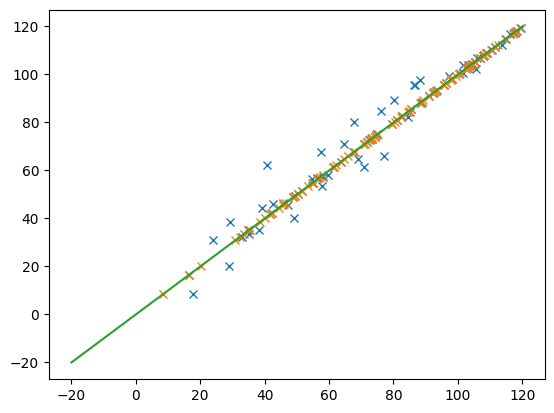

In [72]:
plt.plot(df["sp_calculated_total_u"], df["selected plan utility"], "x") #planned: calculated versus MATSIM (experirenced)
plt.plot(df["ep_calculated_total_u"], df["experienced plan utility"], "x") #experienced: calculated versus MATSIM (experirenced) - this should line up
lista = [-20, 50, 120]
plt.plot(lista, lista)

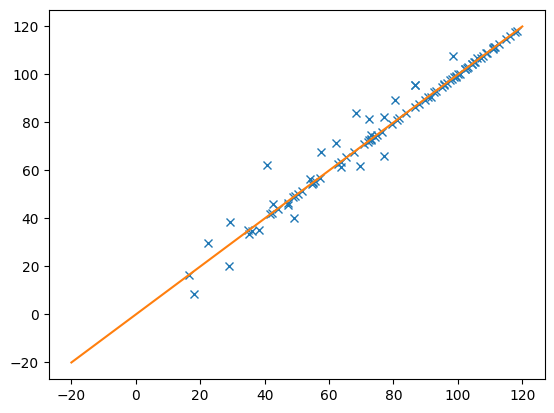

In [73]:
plt.plot(df["up1_calculated_total_u"], df["unselected plan (1) utility"], "x") #planned: calculated versus MATSIM (experirenced)
lista = [-20, 50, 120]
plt.plot(lista, lista)

In [74]:
# df["diff"] = df["up1_calculated_total_u"]-df["unselected plan (1) utility"]
# diffs = list(df["diff"])
# j=0
# for i in range(len(diffs)):
#     if abs(diffs[i]>1) :
#         print("i: "+str(i))
#         print("id: "+str(df.iloc[i]["id"]))
#         print(df.iloc[i]["subpopulation"])
#         print(df.iloc[i]["diff"])
#         j+=1
# print(j)

In [75]:
diff_across_runs = len(df[df["selected plan activity_type_or_mode"]!=df["unselected plan (1) activity_type_or_mode"]])
print(f"the number of agents with difference across runs is {diff_across_runs} or {diff_across_runs/len(df) * 100}%")

the number of agents with difference across runs is 17 or 17.708333333333336%


## Time for flex calcs - mode choice flex

### On the first trip of the day

In [76]:
df_flex = df

In [77]:
#collect the trips into lists
df_flex["sp_trips_groups"] = df.apply(lambda row: moa.group_legs_into_trips(row["selected plan activity_type_or_mode"], row["sp_activities_indices"], row["sp_stuck_index"]), axis=1)
df_flex["up1_trips_groups"] = df.apply(lambda row: moa.group_legs_into_trips(row["unselected plan (1) activity_type_or_mode"], row["up1_activities_indices"], row["up1_stuck_index"]), axis=1)
df_flex["trips_modes"] = df_flex[["sp_trips_groups", "up1_trips_groups"]].apply(lambda row: list(row), axis=1)
df_flex["travel_utilities"] = df_flex[["sp_calculated_travel_u", "up1_calculated_travel_u"]].apply(lambda row: list(row), axis=1)
df_flex["activity_utilities"] = df_flex[["sp_calculated_activity_u", "up1_calculated_activity_u"]].apply(lambda row: list(row), axis=1)

In [78]:
def summariseAdjacentLegs(trips):
    final_new_trips = []
    # print(trips)
    for sublist_i in trips: 
        sub_new_trips = []
        for sublist_j in sublist_i:
            temp = [
                item for i, item in enumerate(sublist_j) 
                if i == 0 or item != sublist_j[i - 1]
            ]
            # print(temp)
            sub_new_trips.append(temp)
        final_new_trips.append(sub_new_trips)
    return(final_new_trips)

In [79]:
#collapse trips e.g, from walk, walk, bus to walk, bus
df["trips_modes_summarised"] = df["trips_modes"].apply(summariseAdjacentLegs)

In [80]:
#turn the first modes and first durations, and overall utilities into their own columns
df["first_trip_modes"] = df["trips_modes_summarised"].apply(lambda x: [inner[0] if isinstance(inner, list) and inner else None for inner in x] if isinstance(x, list) else None)
df["first_trip_travel_u"] = df["travel_utilities"].apply(lambda x: [inner[0] if isinstance(inner, list) and inner else None for inner in x] if isinstance(x, list) else None)
df["first_trip_activity_u"] = df["activity_utilities"].apply(lambda x: [inner[1] if isinstance(inner, list) and inner else None for inner in x] if isinstance(x, list) else None)

In [81]:
#so this function just looks at the highest scoring unique modes, agnostic of which the selected plan is
#but i think we need something to be an anchor since this whole thing is relative and comparative
def trips_to_keep(modes, travel_u, activity_u):
    if not modes:
        return [], [], []
    if not (len(modes) == len(travel_u) == len(activity_u)):
        raise ValueError("All three lists must have the same length")
    if not len(modes)>1:
        raise ValueError("Need at least 2 activities and 1 mode: sruck agent or bad plan")
    # handle single-element case
    if len(modes) == 1:
        return (
            [tuple(modes[0]) if isinstance(modes[0], list) else modes[0]],
            [travel_u[0]],
            [activity_u[0]]
        )

    modes_fixed = [tuple(m) if isinstance(m, list) else m for m in modes]
    first_key = modes_fixed[0]
    # best per key -> (value, index)
    best = {}

    # scan items after index 0
    for idx in range(1, len(modes_fixed)):
        k = modes_fixed[idx]
        if k == first_key:
            continue
        v = travel_u[idx]
        if k not in best or v > best[k][0] or (v == best[k][0] and idx < best[k][1]):
            best[k] = (v, idx)

    # preserve order by the chosen item index (stable order)
    chosen_indices = [best[k][1] for k in sorted(best, key=lambda kk: best[kk][1])]

    # build output lists: prepend index 0
    modes_fixed   = [modes_fixed[0]] + [modes_fixed[i] for i in chosen_indices]
    travel_u_fixed = [travel_u[0]] + [travel_u[i] for i in chosen_indices]
    activity_u_fixed = [activity_u[0]] + [activity_u[i] for i in chosen_indices]

    return modes_fixed, travel_u_fixed, activity_u_fixed


In [82]:
def calculate_flex_score(modes, travel_u, activity_u):
    components = [0,0,0,0] #maxium of 5 different modes giving 4 different flexes (can vary) 
    k = 2.944
    beta = 0.037
    
    modes, travel_u, activity_u = trips_to_keep(modes, travel_u, activity_u)
    for i in range(1, len(modes)):
        try:
            activity_u_ratio = (activity_u[0]-activity_u[i])/activity_u[0]
        except ZeroDivisionError:
            activity_u_ratio = 0
        print(f"activity u ratio: {activity_u_ratio}")
        try:
            travel_u_ratio = (travel_u[0]-travel_u[i])/travel_u[0]
        except ZeroDivisionError:
            travel_u_ratio = 0
        print(f"travel u ratio: {travel_u_ratio}")
        if travel_u_ratio * activity_u_ratio >= 0:
            sigma = -1
        else:
            sigma = 1
        print(f"sigma: {sigma}")
        temp = (2/(1+np.exp(k*abs(travel_u_ratio)*np.exp(sigma*beta*abs(activity_u_ratio))))) 
        print(f"temp: {temp}")
        components[i-1]= (temp)
    return(np.sum(components))

Calibrate alpha and beta

In [83]:
f_at_1 = 0.1
print(f"for a flex score of {f_at_1} at 100% time difference, k should be: {np.log((2/f_at_1)-1)}")

for a flex score of 0.1 at 100% time difference, k should be: 2.9444389791664403


In [84]:
ktemp = 2.944
btemp = 1
difftemp = 0.09
print(f"for alpha={ktemp}, beta should be: {(1/btemp)*np.log((1/ktemp)*np.log((2/difftemp)-1))} for a {difftemp} difference at b of {btemp}")

for alpha=2.944, beta should be: 0.037026382041656564 for a 0.09 difference at b of 1


In [85]:
m = ["car", "bike"]
t = [-30, -40]
a = [100, 80]

In [86]:
calculate_flex_score(m,t,a)

activity u ratio: 0.2
travel u ratio: -0.3333333333333333
sigma: 1
temp: 0.5423686352334225


np.float64(0.5423686352334225)

In [87]:
df_flex["f_score"]=df_flex.apply(lambda row: calculate_flex_score(row["first_trip_modes"], row["first_trip_travel_u"], row["first_trip_activity_u"]), axis=1)

activity u ratio: -0.02782413844503262
travel u ratio: 0.48415000566953614
sigma: 1
temp: 0.3871937474471733
activity u ratio: -0.0068195200540856924
travel u ratio: 0.4816200209572091
sigma: 1
temp: 0.38987304392147215
activity u ratio: 0.024213393683023093
travel u ratio: -0.9047757667395198
sigma: 1
temp: 0.13001361083173574
activity u ratio: 0.7885448473432939
travel u ratio: 0.379798547586707
sigma: -1
temp: 0.5047537196484184
activity u ratio: -0.00714252626677819
travel u ratio: 0.39795441592307523
sigma: 1
temp: 0.47302797354926956
activity u ratio: 0.005382010375108211
travel u ratio: -0.6912201517491758
sigma: 1
temp: 0.2310806341738736


In [88]:
df_flex["f_score"].unique()

array([0.        , 0.38719375, 0.38987304, 0.13001361, 0.50475372,
       0.47302797, 0.23108063])

(array([90.,  0.,  0.,  0.,  0.,  1.,  0.,  0.,  0.,  1.,  0.,  0.,  0.,
         0.,  0.,  2.,  0.,  0.,  1.,  1.]),
 array([0.        , 0.02523769, 0.05047537, 0.07571306, 0.10095074,
        0.12618843, 0.15142612, 0.1766638 , 0.20190149, 0.22713917,
        0.25237686, 0.27761455, 0.30285223, 0.32808992, 0.3533276 ,
        0.37856529, 0.40380298, 0.42904066, 0.45427835, 0.47951603,
        0.50475372]),
 <BarContainer object of 20 artists>)

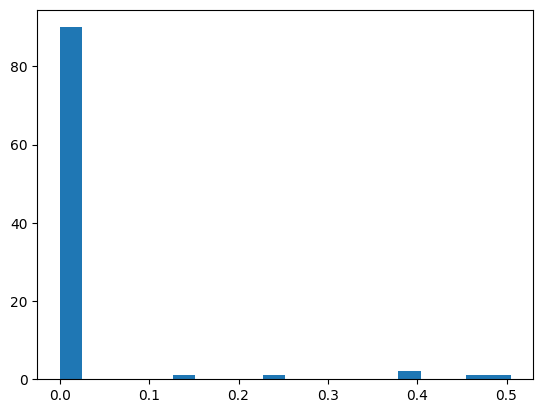

: 

In [ ]:
plt.hist(df_flex["f_score"],bins=20)

## Route flex

## Time flex - need to think about how to do this from MASim